In [1]:
import numpy as np
import requests
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.nn import functional as F

import tiktoken

## Softmax applied multiple times

Experiment: does the **number of points** affect what softmax does?

- 3 vectors: `linspace(0, 1, N)` for **N = 4, 10, 100**
- Each vector goes through softmax **0, 1, and 2 times**

Rows = vector size, Columns = number of softmax applications.

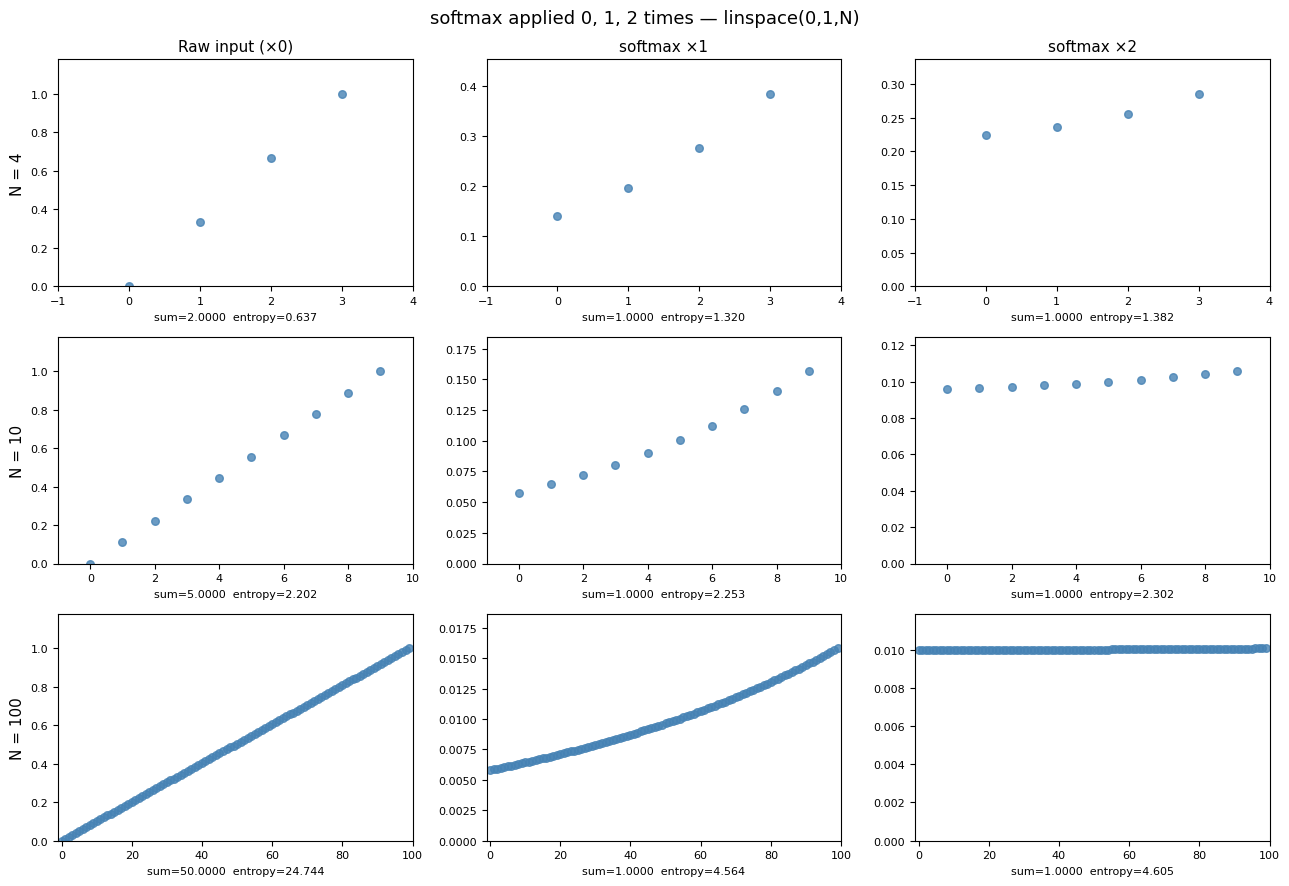

In [5]:
def softmax(x):
    e = np.exp(x - x.max())  # numerical stability
    return e / e.sum()

Ns = [4, 10, 100]
titles = ["Raw input (×0)", "softmax ×1", "softmax ×2"]

fig, axes = plt.subplots(3, 3, figsize=(13, 9))
fig.suptitle("softmax applied 0, 1, 2 times — linspace(0,1,N)", fontsize=13)

for row, N in enumerate(Ns):
    x0 = np.linspace(0, 1, N)
    x1 = softmax(x0)
    x2 = softmax(x1)

    for col, (stage, title) in enumerate(zip([x0, x1, x2], titles)):
        ax = axes[row, col]
        ax.scatter(range(N), stage, color="steelblue", alpha=0.8, s=30)
        if row == 0:
            ax.set_title(title, fontsize=11)
        if col == 0:
            ax.set_ylabel(f"N = {N}", fontsize=11)
        ax.set_xlim(-1, N)
        ax.set_ylim(0, stage.max() * 1.18)
        ax.tick_params(labelsize=8)

        ent = -np.sum(stage * np.log(stage + 1e-12))
        ax.set_xlabel(f"sum={stage.sum():.4f}  entropy={ent:.3f}", fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Important take: the number of data values (e.g. vocab size) impacts the probability values, because they all must sum 1.

### What is happening here?

**Softmax always produces a probability distribution** — its outputs always sum to exactly 1, regardless of the input scale or number of elements. This is by design: softmax converts arbitrary real numbers (logits) into non-negative weights that sum to 1, making them interpretable as probabilities.

$$\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$$

---

**Column 1 — Raw input `linspace(0, 1, N)`**  
A uniform ramp from 0 to 1. The values do *not* sum to 1 (they sum to N/2), and they are spread linearly. No probability interpretation yet.

**Column 2 — After softmax ×1**  
The distribution becomes exponential: each value is proportional to $e^{x_i}$, so higher inputs get disproportionately more weight. The last element dominates. The sum is now exactly 1. Notice the effect is **stronger as N grows**: the input range [0, 1] stays the same but there are more points competing for the total probability mass, so the last point concentrates even more of it.

**Column 3 — After softmax ×2**  
Softmax is applied to the output of the first softmax — which is already a distribution with values between 0 and 1. Because all inputs are now small (most are close to 0), $e^x \approx 1 + x$ for all of them, so the exponentials are much closer to each other. The result is a **much more uniform distribution**: applying softmax a second time partially *undoes* the sharpening of the first pass. The sum is still exactly 1.

---

**Key takeaway:** softmax is not idempotent. Applying it twice does not give the same result as applying it once. The second application flattens the distribution because the first application has already squashed the values into [0, 1], where the exponential function is nearly linear — and a linear function of a probability vector yields a near-uniform distribution.